In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
#Generating our own dataset
x=6*np.random.rand(200,1)-3
y=0.8* x**2 + 0.9 * x +2 + np.random.randn(200,1)

#y=0.8x^2 + 0.9x + 2

Text(0, 0.5, 'Y')

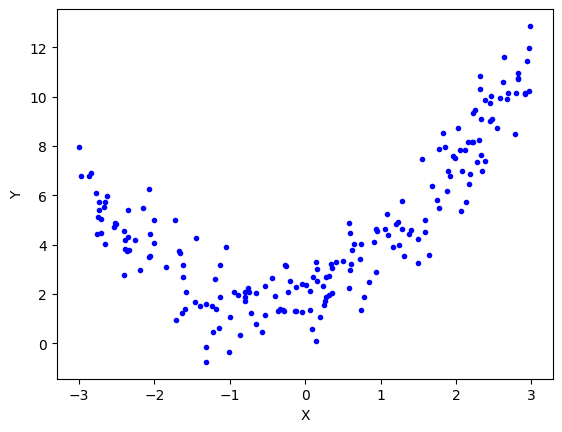

In [4]:
plt.plot(x,y,'b.')
plt.xlabel('X')
plt.ylabel('Y')

In [5]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [6]:
lr=LinearRegression()

In [8]:
lr.fit(x_train,y_train)

LinearRegression()

In [10]:
y_pred=lr.predict(x_test)

In [11]:
r2_score(y_test,y_pred)

0.3215716467741019

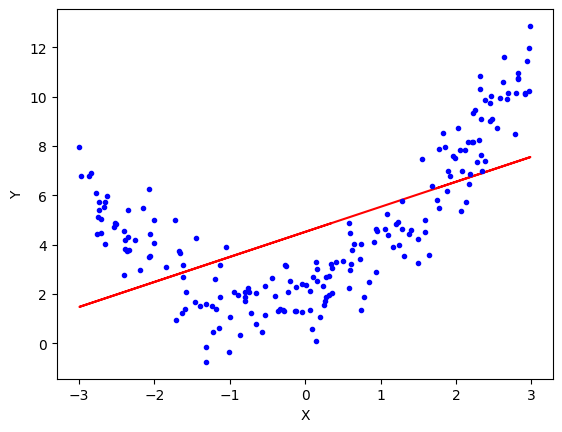

In [14]:
plt.plot(x_train,lr.predict(x_train),color='r')
plt.plot(x,y,'b.')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [15]:
#applying polynomial Linear Regression
#Degree 2
poly=PolynomialFeatures(degree=2)

x_train_trans=poly.fit_transform(x_train)
x_test_trans=poly.transform(x_test)

In [17]:
print(x_train[0])
print(x_train_trans[0]) #x^0   x^1    x^2

[1.74978141]
[1.         1.74978141 3.06173497]


In [18]:
lr=LinearRegression()
lr.fit(x_train_trans,y_train)

LinearRegression()

In [19]:
y_pred=lr.predict(x_test_trans)

In [20]:
r2_score(y_test,y_pred)

0.8501817637159781

In [21]:
lr.coef_

array([[0.        , 0.9294847 , 0.81271693]])

In [22]:
lr.intercept_

array([1.94460813])

In [24]:
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new)
y_new=lr.predict(x_new_poly)

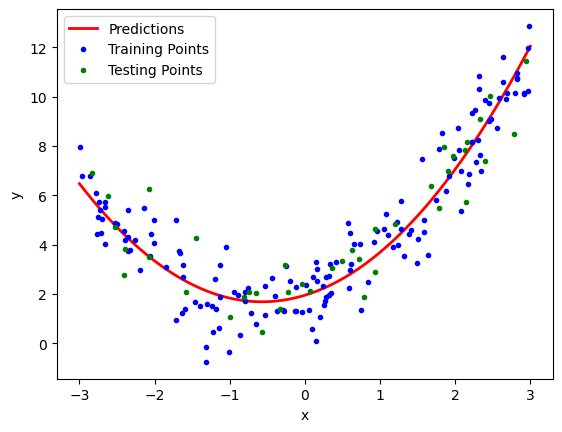

In [25]:
plt.plot(x_new,y_new,'r-',linewidth=2,label='Predictions')
plt.plot(x_train,y_train,'b.',label='Training Points')
plt.plot(x_test,y_test,'g.',label='Testing Points')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [36]:
def polynomial_regression(degree):
    x_new=np.linspace(-3,3,100).reshape(100,1)
    x_new_poly=poly.transform(x_new)

    polybig_features=PolynomialFeatures(degree=degree,include_bias=False)
    std_scaler=StandardScaler()
    lin_reg=LinearRegression()
    polynomial_regression=Pipeline([
        ("poly_features",polybig_features),
        ("std_scaler",std_scaler),
        ("lin_reg",lin_reg),
    ])
    polynomial_regression.fit(x,y)
    y_newbig=polynomial_regression.predict(x_new)
    plt.plot(x_new,y_newbig,"r",label="degree"+str(degree),linewidth=2)

    plt.plot(x_train,y_train,'b.',linewidth=3)
    plt.plot(x_test,y_test,'g.',linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis([-3,3,0,10])
    plt.show()

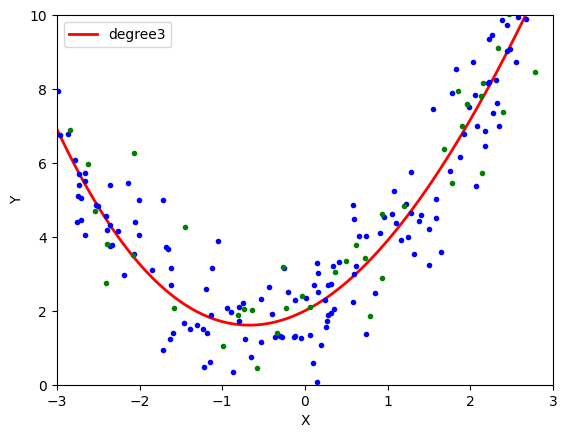

In [37]:
polynomial_regression(3)

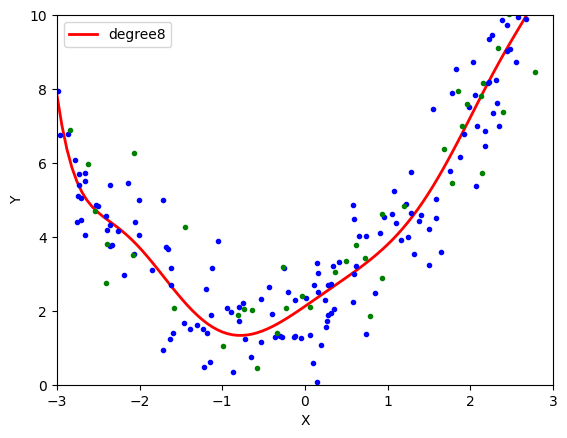

In [39]:
polynomial_regression(8)

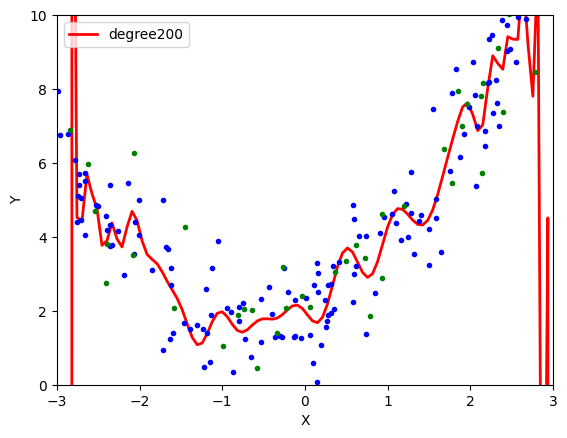

In [40]:
polynomial_regression(200)

### 3D polynomial regression

In [41]:
x=7*np.random.rand(100,1)-2.8
y=7*np.random.rand(100,1)-2.8
z=x**2 + y**2 + 0.2 * x + 0.2 * y + 0.1 * x * y + 2 + np.random.randn(100,1)

#z=x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2